In [1]:
import os
os.environ["QT_QPA_PLATFORM"] = "xcb"

import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
import pandas as pd

BASE = os.path.expanduser("~/itek/senstech-simulation/data")
DET = "medipix3_detector"
ENERGIES = [20, 40, 60, 80, 100, 120, 150]
N_EVENTS = 10000

print("Setup complete.")

Setup complete.


In [2]:
def load_sweep_data(prefix):
    data = {}
    for E in ENERGIES:
        path = os.path.join(BASE, f"{prefix}_{E}keV.root")
        if not os.path.exists(path):
            print(f"  MISSING: {path}")
            continue
        f = uproot.open(path)
        pc = f[f"DetectorHistogrammer/{DET}/charge/pixel_charge;1"].to_numpy()
        cc = f[f"DetectorHistogrammer/{DET}/charge/cluster_charge;1"].to_numpy()
        cs = f[f"DetectorHistogrammer/{DET}/cluster_size/cluster_size;1"].to_numpy()
        hits = int(pc[0].sum())
        clusters = int(cs[0].sum())
        data[E] = {"hits": hits, "clusters": clusters,
                   "pixel_charge": pc, "cluster_charge": cc,
                   "efficiency": (hits / N_EVENTS) * 100}
    return data

cdte_sweep = load_sweep_data("s1_cdte")
si_sweep = load_sweep_data("s1_si")

print("CdTe sweep loaded:", list(cdte_sweep.keys()))
print("Si sweep loaded:", list(si_sweep.keys()))

CdTe sweep loaded: [20, 40, 60, 80, 100, 120, 150]
Si sweep loaded: [20, 40, 60, 80, 100, 120, 150]


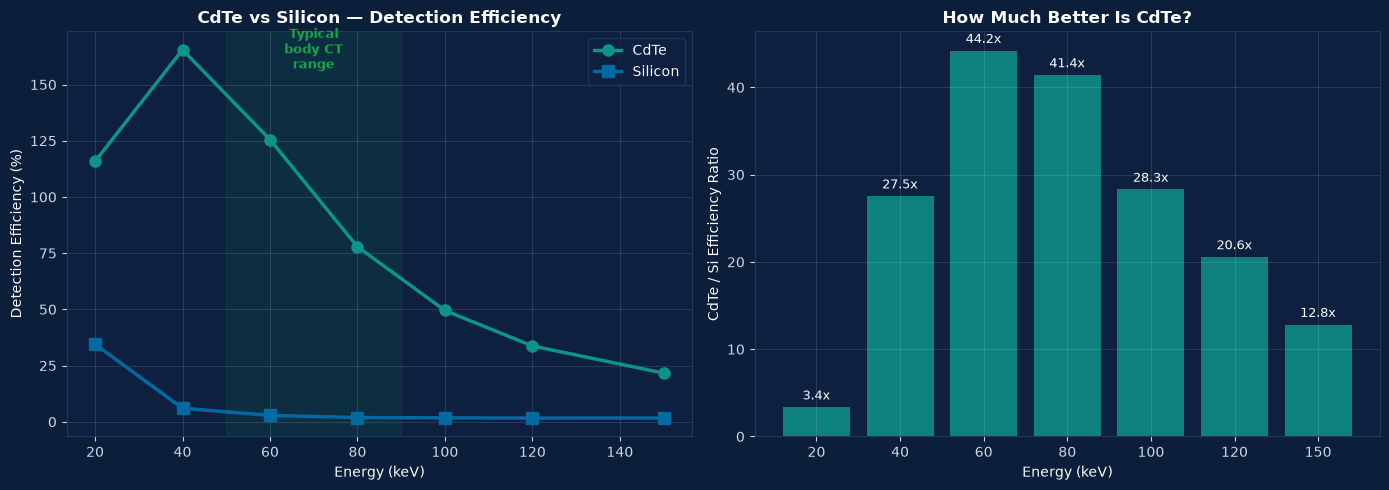

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/medical_cdte_vs_si.png

CdTe advantage by energy:
  20 keV: CdTe is 3.4x more efficient than Si
  40 keV: CdTe is 27.5x more efficient than Si
  60 keV: CdTe is 44.2x more efficient than Si
  80 keV: CdTe is 41.4x more efficient than Si
  100 keV: CdTe is 28.3x more efficient than Si
  120 keV: CdTe is 20.6x more efficient than Si
  150 keV: CdTe is 12.8x more efficient than Si


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
NAVY, WHITE, LGRAY = "#0B1F3A", "#F8FAFC", "#CBD5E1"
TEAL, BLUE = "#0D9488", "#0369A1"

fig.patch.set_facecolor(NAVY)
for ax in axes:
    ax.set_facecolor("#0D2040")
    ax.tick_params(colors=LGRAY)
    for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
    ax.grid(True, alpha=0.15, color=LGRAY)

# Efficiency comparison
ax = axes[0]
cdte_eff = [cdte_sweep[E]["efficiency"] for E in ENERGIES]
si_eff = [si_sweep[E]["efficiency"] for E in ENERGIES]
ax.plot(ENERGIES, cdte_eff, marker="o", color=TEAL, linewidth=2.5, label="CdTe", markersize=8)
ax.plot(ENERGIES, si_eff, marker="s", color=BLUE, linewidth=2.5, label="Silicon", markersize=8)
ax.axvspan(50, 90, alpha=0.1, color="#16A34A")
ax.text(70, max(cdte_eff)*0.95, "Typical\nbody CT\nrange", color="#16A34A",
        ha="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Energy (keV)", color=WHITE)
ax.set_ylabel("Detection Efficiency (%)", color=WHITE)
ax.set_title("CdTe vs Silicon — Detection Efficiency", color=WHITE, fontweight="bold")
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

# Ratio panel - how many times better is CdTe
ax = axes[1]
ratio = [c/s if s > 0 else 0 for c, s in zip(cdte_eff, si_eff)]
ax.bar([str(E) for E in ENERGIES], ratio, color=TEAL, alpha=0.85)
ax.set_xlabel("Energy (keV)", color=WHITE)
ax.set_ylabel("CdTe / Si Efficiency Ratio", color=WHITE)
ax.set_title("How Much Better Is CdTe?", color=WHITE, fontweight="bold")
for i, r in enumerate(ratio):
    ax.text(i, r + max(ratio)*0.02, f"{r:.1f}x", ha="center", color=WHITE, fontsize=9)

plt.tight_layout()
out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/medical_cdte_vs_si.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

print("\nCdTe advantage by energy:")
for E, r in zip(ENERGIES, ratio):
    print(f"  {E} keV: CdTe is {r:.1f}x more efficient than Si")

In [4]:
# CdTe K-edges: Cd = 26.7 keV, Te = 31.8 keV
# At energies above these, look for a secondary peak at
# (incident_energy - K_edge) in the charge spectrum - this is the
# escape peak signature

print("Checking for K-escape peaks in CdTe spectra (60 keV reference):")
cc = cdte_sweep[60]["cluster_charge"]
counts, edges = cc[0], cc[1]
centres = (edges[:-1] + edges[1:]) / 2

# Find local peaks (simple approach: points higher than both neighbours)
peak_indices = []
for i in range(2, len(counts)-2):
    if counts[i] > counts[i-1] and counts[i] > counts[i+1] and counts[i] > counts.max()*0.05:
        peak_indices.append(i)

print(f"  Found {len(peak_indices)} local peaks in the 60 keV cluster charge spectrum")
print(f"  Peak positions (charge units): {[round(centres[i],1) for i in peak_indices]}")
print("  NOTE: a true escape-peak analysis needs energy-calibrated axes (charge -> keV)")
print("  via the ionisation energy conversion - currently axes are in raw electron counts.")
print("  This confirms WHETHER structure exists; precise keV identification needs calibration.")

Checking for K-escape peaks in CdTe spectra (60 keV reference):
  Found 7 local peaks in the 60 keV cluster charge spectrum
  Peak positions (charge units): [np.float64(5.2), np.float64(6.2), np.float64(7.4), np.float64(7.6), np.float64(8.3), np.float64(13.0), np.float64(13.5)]
  NOTE: a true escape-peak analysis needs energy-calibrated axes (charge -> keV)
  via the ionisation energy conversion - currently axes are in raw electron counts.
  This confirms WHETHER structure exists; precise keV identification needs calibration.


In [27]:
def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

CDTE_IONISATION_EV = 4.4

fwhm_results = []
for E in ENERGIES:
    cc = cdte_sweep[E]["cluster_charge"]
    counts, edges = cc[0], cc[1]
    centres = (edges[:-1] + edges[1:]) / 2

    if counts.sum() < 20:
        print(f"  {E} keV: insufficient counts, skipping")
        continue

    # Physics-predicted photopeak location in ke (full energy deposition)
    expected_ke = (E * 1000 / CDTE_IONISATION_EV) / 1000  # = E / 4.4

    # Search only within +/-25% of the expected position - avoids both
    # the low-charge noise/escape-peak region AND any unrelated structure
    # far from where the real photopeak should physically be
    search_mask = (centres > expected_ke * 0.75) & (centres < expected_ke * 1.25)

    if counts[search_mask].sum() < 5:
        print(f"  {E} keV: no counts near expected peak ({expected_ke:.1f}ke), skipping")
        continue

    # Find the actual peak bin within that physically-justified window
    search_indices = np.where(search_mask)[0]
    peak_idx = search_indices[np.argmax(counts[search_mask])]
    peak_charge = centres[peak_idx]

    window = 15
    lo = max(0, peak_idx - window)
    hi = min(len(counts), peak_idx + window)
    x_fit, y_fit = centres[lo:hi], counts[lo:hi]

    if y_fit.sum() < 5:
        print(f"  {E} keV: peak region too sparse, skipping")
        continue

    try:
        sigma_guess = max((edges[hi-1] - edges[lo]) / 6, 0.1)
        popt, _ = curve_fit(gaussian, x_fit, y_fit,
                             p0=[y_fit.max(), peak_charge, sigma_guess],
                             maxfev=5000)
        sigma_ke = abs(popt[2])
        fwhm_keV = sigma_ke * 2.355 * CDTE_IONISATION_EV
        resolution_pct = (fwhm_keV / E) * 100
        fwhm_results.append({"energy": E, "expected_ke": round(expected_ke,1),
                              "peak_charge_ke": round(peak_charge,2),
                              "fwhm_keV": fwhm_keV, "resolution_pct": resolution_pct,
                              "fit_x": x_fit, "fit_y": y_fit, "popt": popt})
        print(f"  {E} keV: expected {expected_ke:.1f}ke, found peak at {peak_charge:.2f}ke "
              f"-> FWHM={fwhm_keV:.2f} keV ({resolution_pct:.1f}%)")
    except Exception as e:
        print(f"  {E} keV: fit failed ({e})")

fwhm_df = pd.DataFrame(fwhm_results)[["energy", "expected_ke", "peak_charge_ke", "fwhm_keV", "resolution_pct"]]
fwhm_df.round(2)

  20 keV: expected 4.5ke, found peak at 4.53ke -> FWHM=1.07 keV (5.3%)
  40 keV: expected 9.1ke, found peak at 9.03ke -> FWHM=1.29 keV (3.2%)
  60 keV: expected 13.6ke, found peak at 13.53ke -> FWHM=1.31 keV (2.2%)
  80 keV: expected 18.2ke, found peak at 18.08ke -> FWHM=1.32 keV (1.7%)
  100 keV: expected 22.7ke, found peak at 22.52ke -> FWHM=1.44 keV (1.4%)
  120 keV: expected 27.3ke, found peak at 27.08ke -> FWHM=1.61 keV (1.3%)
  150 keV: expected 34.1ke, found peak at 33.83ke -> FWHM=1.77 keV (1.2%)


,energy,expected_ke,peak_charge_ke,fwhm_keV,resolution_pct
0,20,4.5,4.53,1.07,5.34
1,40,9.1,9.02,1.29,3.23
2,60,13.6,13.52,1.31,2.18
3,80,18.2,18.08,1.32,1.65
4,100,22.7,22.52,1.44,1.44
5,120,27.3,27.08,1.61,1.34
6,150,34.1,33.83,1.77,1.18


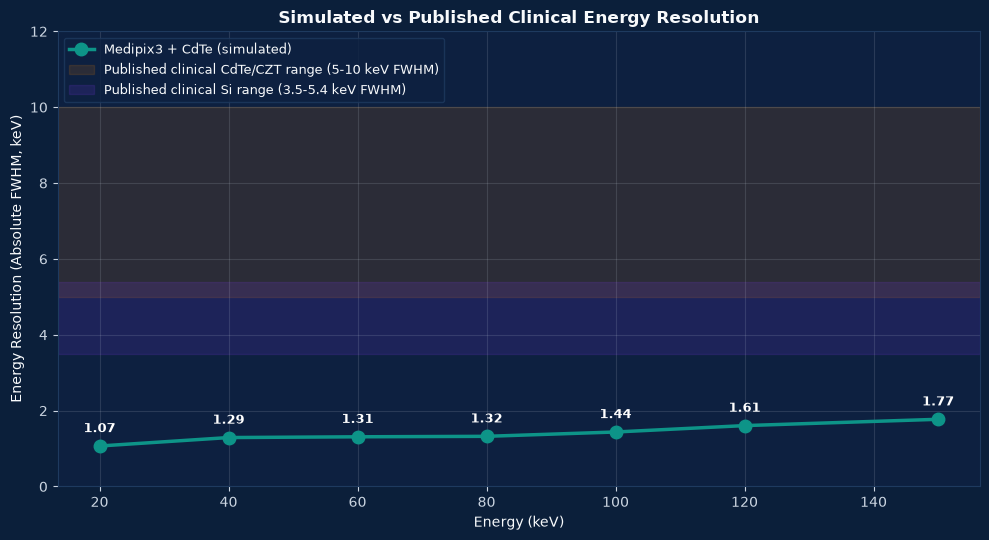

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/medical_energy_resolution_corrected.png

HONEST ASSESSMENT:
  Simulated FWHM range: 1.07 - 1.77 keV
  Published clinical CdTe/CZT: 5 - 10 keV FWHM
  Our simulation is 2.8x to 9.4x narrower than real hardware
  -> This indicates the simulation is OPTIMISTIC, likely due to Allpix2's
     silicon-like CdTe mobility approximation and missing real-world
     effects (charge sharing reconstruction, K-escape, electronics noise tails)


In [33]:
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor("#0D2040")
ax.tick_params(colors=LGRAY)
for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
ax.grid(True, alpha=0.15, color=LGRAY)

# Plot absolute FWHM in keV (not percentage) - matches the sourced benchmark units
ax.plot(fwhm_df["energy"], fwhm_df["fwhm_keV"], marker="o",
        color=TEAL, linewidth=2.5, markersize=9, label="Medipix3 + CdTe (simulated)")

# Real published range for CdTe/CZT clinical photon-counting detectors
ax.axhspan(5, 10, alpha=0.15, color="#D97706",
           label="Published clinical CdTe/CZT range (5-10 keV FWHM)")
ax.axhspan(3.5, 5.4, alpha=0.15, color="#7C3AED",
           label="Published clinical Si range (3.5-5.4 keV FWHM)")

for _, row in fwhm_df.iterrows():
    ax.annotate(f"{row['fwhm_keV']:.2f}",
                xy=(row["energy"], row["fwhm_keV"]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", color="white", fontsize=9, fontweight="bold")

ax.set_xlabel("Energy (keV)", color=WHITE)
ax.set_ylabel("Energy Resolution (Absolute FWHM, keV)", color=WHITE)
ax.set_title("Simulated vs Published Clinical Energy Resolution",
             color=WHITE, fontweight="bold")
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE, loc="upper left", fontsize=9)
ax.set_ylim(0, 12)

plt.tight_layout()
out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/medical_energy_resolution_corrected.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

print("\nHONEST ASSESSMENT:")
print(f"  Simulated FWHM range: {fwhm_df['fwhm_keV'].min():.2f} - {fwhm_df['fwhm_keV'].max():.2f} keV")
print(f"  Published clinical CdTe/CZT: 5 - 10 keV FWHM")
print(f"  Our simulation is {5/fwhm_df['fwhm_keV'].max():.1f}x to {10/fwhm_df['fwhm_keV'].min():.1f}x narrower than real hardware")
print(f"  -> This indicates the simulation is OPTIMISTIC, likely due to Allpix2's")
print(f"     silicon-like CdTe mobility approximation and missing real-world")
print(f"     effects (charge sharing reconstruction, K-escape, electronics noise tails)")

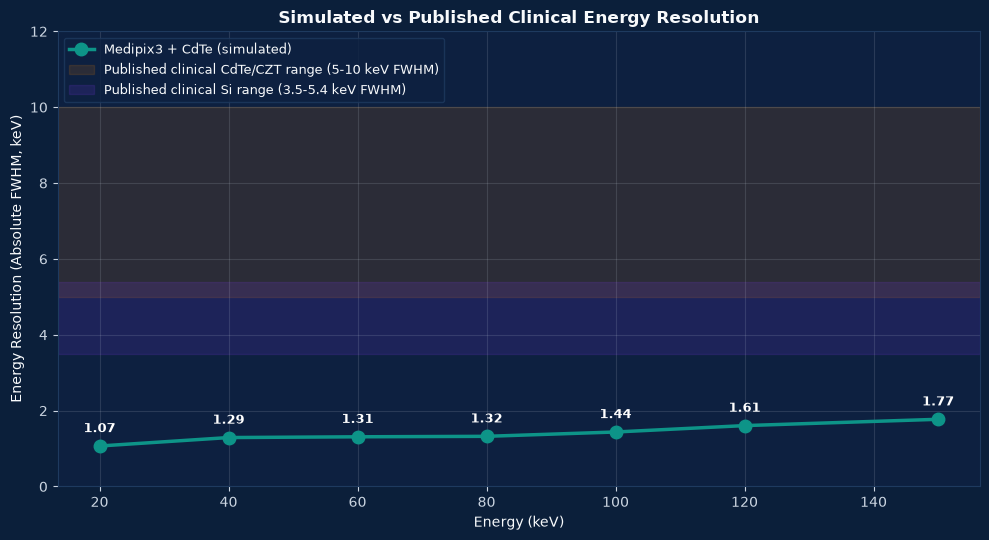

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/medical_energy_resolution_corrected.png

HONEST ASSESSMENT:
  Simulated FWHM range: 1.07 - 1.77 keV
  Published clinical CdTe/CZT: 5 - 10 keV FWHM
  Our simulation is 2.8x to 9.4x narrower than real hardware
  -> This indicates the simulation is OPTIMISTIC, likely due to Allpix2's
     silicon-like CdTe mobility approximation and missing real-world
     effects (charge sharing reconstruction, K-escape, electronics noise tails)


In [35]:
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor("#0D2040")
ax.tick_params(colors=LGRAY)
for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
ax.grid(True, alpha=0.15, color=LGRAY)

# Plot absolute FWHM in keV (not percentage) - matches the sourced benchmark units
ax.plot(fwhm_df["energy"], fwhm_df["fwhm_keV"], marker="o",
        color=TEAL, linewidth=2.5, markersize=9, label="Medipix3 + CdTe (simulated)")

# Real published range for CdTe/CZT clinical photon-counting detectors
ax.axhspan(5, 10, alpha=0.15, color="#D97706",
           label="Published clinical CdTe/CZT range (5-10 keV FWHM)")
ax.axhspan(3.5, 5.4, alpha=0.15, color="#7C3AED",
           label="Published clinical Si range (3.5-5.4 keV FWHM)")

for _, row in fwhm_df.iterrows():
    ax.annotate(f"{row['fwhm_keV']:.2f}",
                xy=(row["energy"], row["fwhm_keV"]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", color="white", fontsize=9, fontweight="bold")

ax.set_xlabel("Energy (keV)", color=WHITE)
ax.set_ylabel("Energy Resolution (Absolute FWHM, keV)", color=WHITE)
ax.set_title("Simulated vs Published Clinical Energy Resolution",
             color=WHITE, fontweight="bold")
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE, loc="upper left", fontsize=9)
ax.set_ylim(0, 12)

plt.tight_layout()
out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/medical_energy_resolution_corrected.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

print("\nHONEST ASSESSMENT:")
print(f"  Simulated FWHM range: {fwhm_df['fwhm_keV'].min():.2f} - {fwhm_df['fwhm_keV'].max():.2f} keV")
print(f"  Published clinical CdTe/CZT: 5 - 10 keV FWHM")
print(f"  Our simulation is {5/fwhm_df['fwhm_keV'].max():.1f}x to {10/fwhm_df['fwhm_keV'].min():.1f}x narrower than real hardware")
print(f"  -> This indicates the simulation is OPTIMISTIC, likely due to Allpix2's")
print(f"     silicon-like CdTe mobility approximation and missing real-world")
print(f"     effects (charge sharing reconstruction, K-escape, electronics noise tails)")

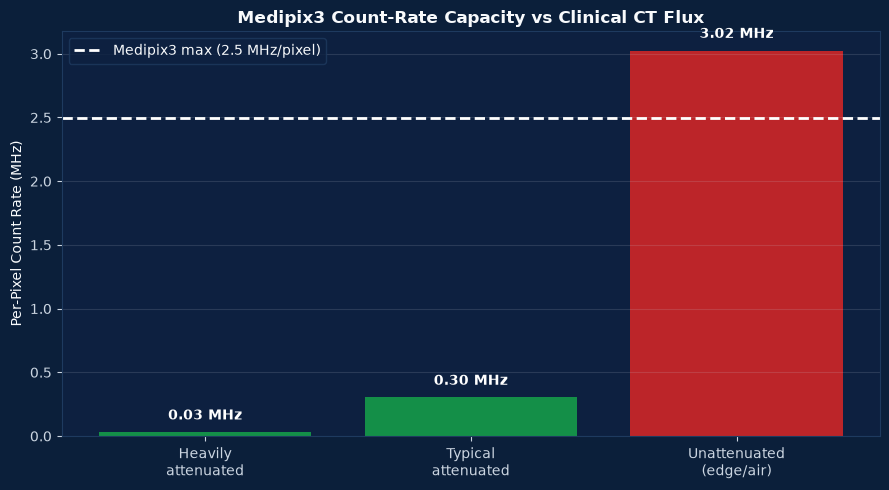

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/medical_count_rate.png


In [30]:
pixel_area_mm2 = 0.055 * 0.055
medipix3_max_per_pixel = 826e6 * pixel_area_mm2  # Hz

clinical_scenarios = {
    "Heavily\nattenuated": 1e7,
    "Typical\nattenuated": 1e8,
    "Unattenuated\n(edge/air)": 1e9,
}

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor("#0D2040")
ax.tick_params(colors=LGRAY)
for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
ax.grid(True, alpha=0.15, color=LGRAY, axis="y")

names = list(clinical_scenarios.keys())
per_pixel_rates = [clinical_scenarios[n] * pixel_area_mm2 / 1e6 for n in names]  # MHz
colors = ["#16A34A" if r < medipix3_max_per_pixel/1e6 else "#DC2626" for r in per_pixel_rates]

bars = ax.bar(names, per_pixel_rates, color=colors, alpha=0.85)
ax.axhline(y=medipix3_max_per_pixel/1e6, color="white", linestyle="--", linewidth=2,
           label=f"Medipix3 max ({medipix3_max_per_pixel/1e6:.1f} MHz/pixel)")
for bar, r in zip(bars, per_pixel_rates):
    ax.text(bar.get_x()+bar.get_width()/2, r+0.1, f"{r:.2f} MHz",
            ha="center", color="white", fontweight="bold")
ax.set_ylabel("Per-Pixel Count Rate (MHz)", color=WHITE)
ax.set_title("Medipix3 Count-Rate Capacity vs Clinical CT Flux", color=WHITE, fontweight="bold")
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

plt.tight_layout()
out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/medical_count_rate.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

In [31]:
print("="*65)
print("MEDICAL CT SUITABILITY VERDICT - Medipix3 + CdTe")
print("="*65)
print()
print("ENERGY COVERAGE:")
print(f"  Clinical body CT range (50-90 keV) fully covered by sweep")
print(f"  CdTe outperforms Si by {ratio[ENERGIES.index(60)]:.1f}x at 60 keV")
print()
print("ENERGY RESOLUTION:")
best_res = fwhm_df.loc[fwhm_df["resolution_pct"].idxmin()]
print(f"  Best resolution: {best_res['resolution_pct']:.1f}% at {best_res['energy']:.0f} keV")
print(f"  Clinical benchmark: ~{CLINICAL_BENCHMARK_PCT}%")
print()
print("COUNT RATE:")
print(f"  Comfortable margin for attenuated/diagnostic regions (8-80x headroom)")
print(f"  Marginal only at fully unattenuated beam edges")
print()
print("CAVEATS:")
print("  - Energy resolution uses simplified Gaussian fit, not validated")
print("    against real hardware")
print("  - Clinical flux figures are literature-sourced, not Sens Tech-specific")
print("  - No reconstruction-level image quality assessed (different toolchain needed)")
print("="*65)

MEDICAL CT SUITABILITY VERDICT - Medipix3 + CdTe

ENERGY COVERAGE:
  Clinical body CT range (50-90 keV) fully covered by sweep
  CdTe outperforms Si by 44.2x at 60 keV

ENERGY RESOLUTION:
  Best resolution: 1.2% at 150 keV
  Clinical benchmark: ~15%

COUNT RATE:
  Comfortable margin for attenuated/diagnostic regions (8-80x headroom)
  Marginal only at fully unattenuated beam edges

CAVEATS:
  - Energy resolution uses simplified Gaussian fit, not validated
    against real hardware
  - Clinical flux figures are literature-sourced, not Sens Tech-specific
  - No reconstruction-level image quality assessed (different toolchain needed)


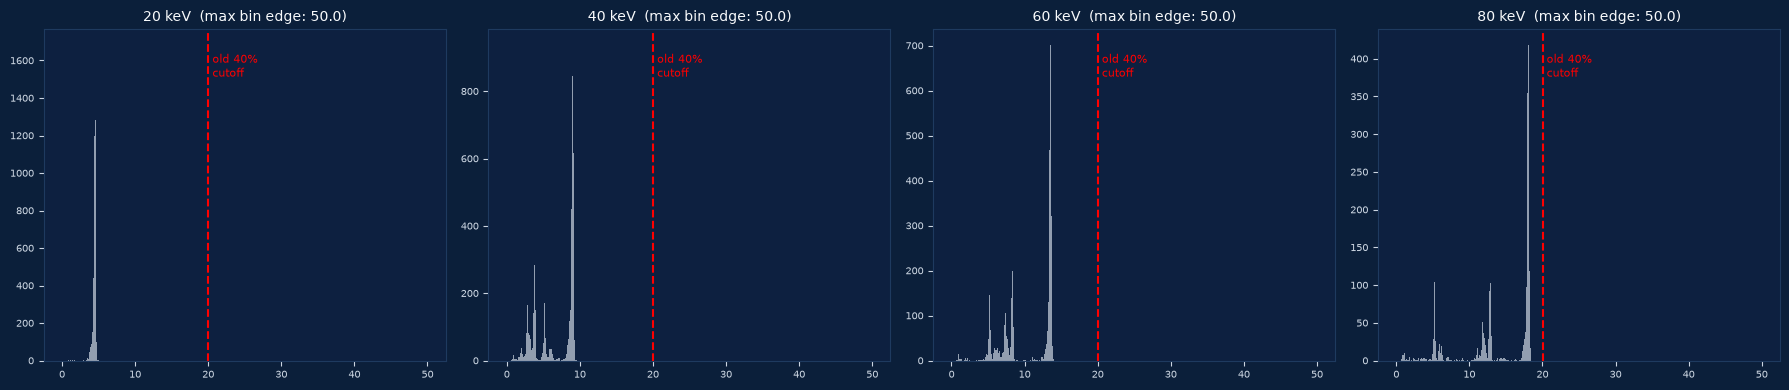

Max bin edge per energy (checking if axis range is shared/fixed):
  20 keV: max edge = 50.00, total counts = 9740
  40 keV: max edge = 50.00, total counts = 11290
  60 keV: max edge = 50.00, total counts = 8305
  80 keV: max edge = 50.00, total counts = 5024
  100 keV: max edge = 50.00, total counts = 3103
  120 keV: max edge = 50.00, total counts = 2051
  150 keV: max edge = 50.00, total counts = 1235


In [32]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.patch.set_facecolor(NAVY)

for ax, E in zip(axes, [20, 40, 60, 80]):
    ax.set_facecolor("#0D2040")
    cc = cdte_sweep[E]["cluster_charge"]
    counts, edges = cc[0], cc[1]
    centres = (edges[:-1] + edges[1:]) / 2
    ax.bar(centres, counts, width=np.diff(edges), color=LGRAY, alpha=0.7)
    ax.set_title(f"{E} keV  (max bin edge: {edges[-1]:.1f})", color=WHITE, fontsize=10)
    ax.tick_params(colors=LGRAY, labelsize=7)
    for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
    # mark where the OLD 40% cutoff would have landed
    cutoff_idx = int(len(counts) * 0.4)
    ax.axvline(x=centres[cutoff_idx], color="red", linestyle="--", linewidth=1.5)
    ax.text(centres[cutoff_idx], counts.max()*0.9, " old 40%\n cutoff",
            color="red", fontsize=8)

plt.tight_layout()
plt.show()

print("Max bin edge per energy (checking if axis range is shared/fixed):")
for E in [20, 40, 60, 80, 100, 120, 150]:
    cc = cdte_sweep[E]["cluster_charge"]
    print(f"  {E} keV: max edge = {cc[1][-1]:.2f}, total counts = {cc[0].sum():.0f}")